# Model 1 — Patient Readmission Prediction

**Dataset:** `healthcare_admissions.csv` (55,500 hospital admission records)

**⚠️ Important note on the target variable:** none of the source files provided (`heart.csv`, `Hospital_Admissions_Data.csv`, `healthcare_dataset.csv`, `healthcare_dataset__1_.csv`, `cleaned_healthcare_dataset.csv`) contain an explicit "readmitted" label. This notebook uses `healthcare_dataset__1_.csv` (renamed here to `healthcare_admissions.csv`) because it is the only file with admission/discharge dates and enough repeat-patient structure to build a readmission signal.

**Proxy target definition:** `Readmitted = 1` if a patient's name appears in **more than one** admission record in the dataset (i.e., they were admitted again at some point), else `0`. This yields a ~19.8% positive class rate — plausible and workable for classification. This is a proxy, not a ground-truth clinical readmission flag (e.g., "readmitted within 30 days") — if you have a dataset with a real readmission column, swap it in and skip Section 2.

Algorithms: **Logistic Regression, Random Forest, XGBoost**
Evaluation: **Accuracy, Precision, Recall, F1 Score, ROC-AUC**

*Author: Nusrat — Data Analyst @ Wmolex pvt ltd*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


## 1. Load Data

In [2]:
df = pd.read_csv('healthcare_admissions.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


In [4]:
print("Missing values:")
print(df.isnull().sum())


Missing values:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


## 2. Engineer the Readmission Target

A patient is marked as **readmitted** if their `Name` appears more than once across the dataset's admission records.


In [5]:
name_counts = df['Name'].value_counts()
df['Readmitted'] = df['Name'].map(name_counts).apply(lambda c: 1 if c > 1 else 0)

print(df['Readmitted'].value_counts())
print(df['Readmitted'].value_counts(normalize=True).round(4))


Readmitted
0    44485
1    11015
Name: count, dtype: int64
Readmitted
0    0.8015
1    0.1985
Name: proportion, dtype: float64


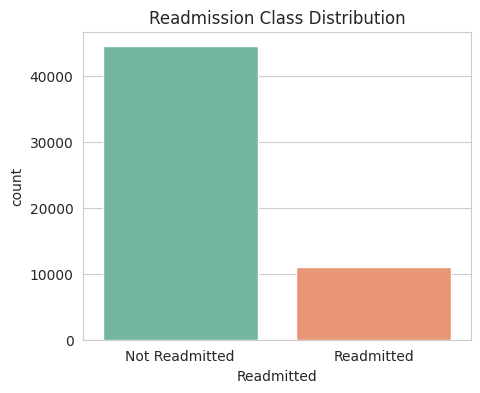

In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Readmitted', palette='Set2')
plt.title('Readmission Class Distribution')
plt.xticks([0, 1], ['Not Readmitted', 'Readmitted'])
plt.show()


## 3. Feature Engineering

- `Date of Admission` / `Discharge Date` → parsed to datetime, used to derive `Length_of_Stay` (days)
- `Admission_Year`, `Admission_Month` extracted for potential seasonal signal
- Raw identifier columns (`Name`, `Doctor`, `Hospital`, `Room Number`) dropped — they are not generalizable predictive features and risk leaking the target (since `Name` was used to build it)


In [7]:
df_fe = df.copy()
df_fe['Date of Admission'] = pd.to_datetime(df_fe['Date of Admission'])
df_fe['Discharge Date'] = pd.to_datetime(df_fe['Discharge Date'])

df_fe['Length_of_Stay'] = (df_fe['Discharge Date'] - df_fe['Date of Admission']).dt.days
df_fe['Admission_Year'] = df_fe['Date of Admission'].dt.year
df_fe['Admission_Month'] = df_fe['Date of Admission'].dt.month

df_fe = df_fe.drop(columns=['Name', 'Doctor', 'Hospital', 'Room Number', 'Date of Admission', 'Discharge Date'])
df_fe.head()


,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results,Readmitted,Length_of_Stay,Admission_Year,Admission_Month
0,30,Male,B-,Cancer,Blue Cross,18856.281306,Urgent,Paracetamol,Normal,0,2,2024,1
1,62,Male,A+,Obesity,Medicare,33643.327287,Emergency,Ibuprofen,Inconclusive,0,6,2019,8
2,76,Female,A-,Obesity,Aetna,27955.096079,Emergency,Aspirin,Normal,0,15,2022,9
3,28,Female,O+,Diabetes,Medicare,37909.782410,Elective,Ibuprofen,Abnormal,0,30,2020,11
4,43,Female,AB+,Cancer,Aetna,14238.317814,Urgent,Penicillin,Abnormal,1,20,2022,9


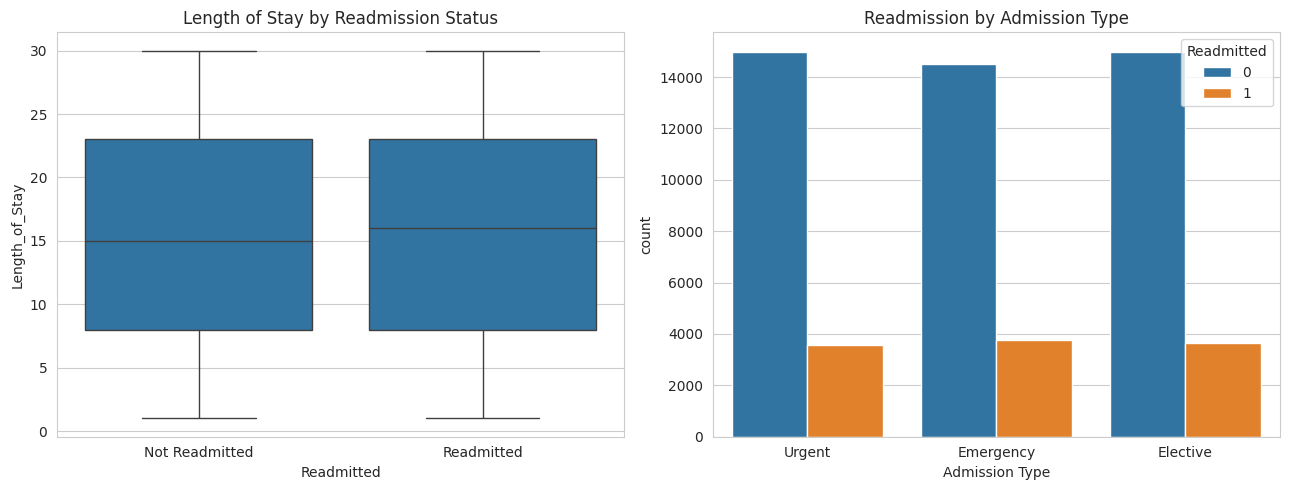

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_fe, x='Readmitted', y='Length_of_Stay', ax=axes[0])
axes[0].set_xticklabels(['Not Readmitted', 'Readmitted'])
axes[0].set_title('Length of Stay by Readmission Status')

sns.countplot(data=df_fe, x='Admission Type', hue='Readmitted', ax=axes[1])
axes[1].set_title('Readmission by Admission Type')
plt.tight_layout()
plt.show()


## 4. Preprocessing Pipeline

In [9]:
target = 'Readmitted'
X = df_fe.drop(columns=[target])
y = df_fe[target]

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']
Numeric columns: ['Age', 'Billing Amount', 'Length_of_Stay', 'Admission_Year', 'Admission_Month']


In [10]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])


## 5. Train / Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train readmission rate: {y_train.mean():.4f} | Test readmission rate: {y_test.mean():.4f}")


Train shape: (44400, 12), Test shape: (11100, 12)
Train readmission rate: 0.1985 | Test readmission rate: 0.1985


## 6. Train Models

Logistic Regression, Random Forest, and XGBoost — each wrapped in the same preprocessing pipeline for a fair comparison. `scale_pos_weight` is set for XGBoost to account for the class imbalance (~80/20 split).


In [12]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, eval_metric='logloss',
        random_state=RANDOM_STATE, use_label_encoder=False
    )
}

fitted_pipelines = {}
pred_results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    pred_results[name] = {'preds': preds, 'probs': probs}
    print(f"{name} trained.")


LogisticRegression trained.


RandomForest trained.


XGBoost trained.


## 7. Evaluation — Accuracy, Precision, Recall, F1, ROC-AUC

In [13]:
metrics_rows = []
for name, r in pred_results.items():
    metrics_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, r['preds']),
        'Precision': precision_score(y_test, r['preds']),
        'Recall': recall_score(y_test, r['preds']),
        'F1': f1_score(y_test, r['preds']),
        'ROC-AUC': roc_auc_score(y_test, r['probs'])
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Model').sort_values('ROC-AUC', ascending=False)
metrics_df.round(4)


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
RandomForest,0.9580,0.9983,0.7898,0.8819,0.9040
XGBoost,0.6156,0.2606,0.5098,0.3448,0.6150
LogisticRegression,0.5094,0.2002,0.4916,0.2846,0.5013


In [14]:
best_model_name = metrics_df.index[0]
best_pipeline = fitted_pipelines[best_model_name]
best_preds = pred_results[best_model_name]['preds']
best_probs = pred_results[best_model_name]['probs']

print(f"Best model by ROC-AUC: {best_model_name}\n")
print(classification_report(y_test, best_preds, target_names=['Not Readmitted', 'Readmitted']))


Best model by ROC-AUC: RandomForest

                precision    recall  f1-score   support

Not Readmitted       0.95      1.00      0.97      8897
    Readmitted       1.00      0.79      0.88      2203

      accuracy                           0.96     11100
     macro avg       0.97      0.89      0.93     11100
  weighted avg       0.96      0.96      0.96     11100



### Confusion Matrix — Best Model

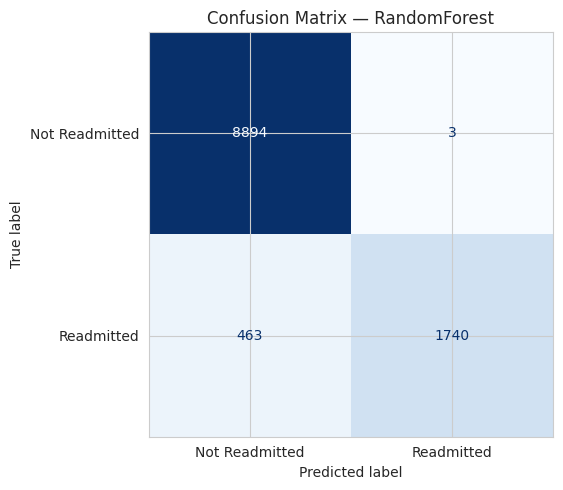

In [15]:
cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()


### ROC Curve — All Models Compared

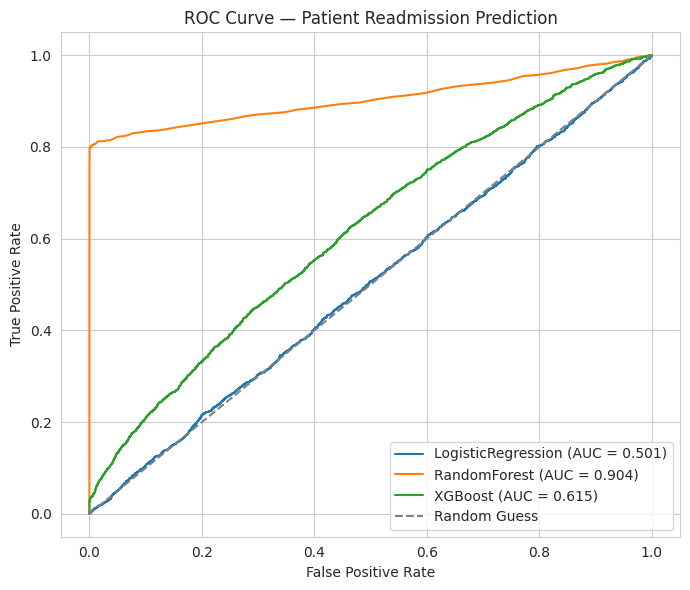

In [16]:
plt.figure(figsize=(7, 6))
for name, r in pred_results.items():
    fpr, tpr, _ = roc_curve(y_test, r['probs'])
    auc = roc_auc_score(y_test, r['probs'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Patient Readmission Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Model Comparison — Bar Chart

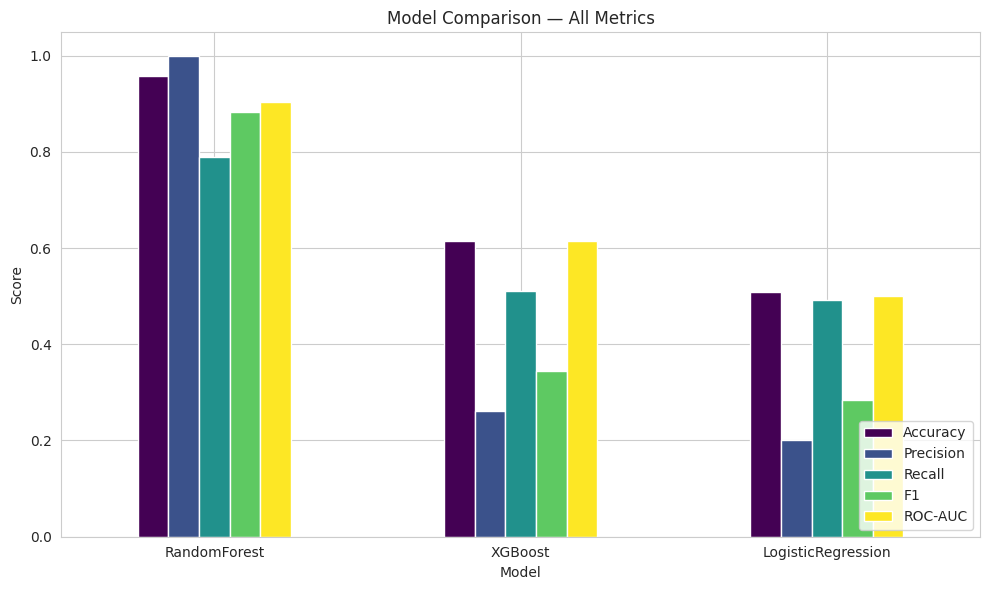

In [17]:
metrics_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar', figsize=(10, 6), colormap='viridis'
)
plt.title('Model Comparison — All Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 8. Feature Importance (Best Tree-Based Model)

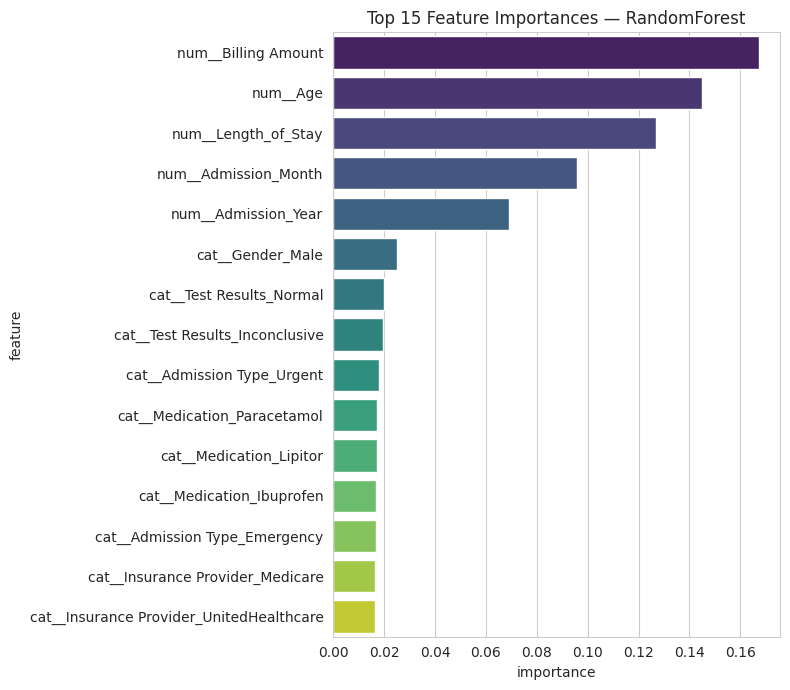

In [18]:
def get_feature_names(pipeline):
    return pipeline.named_steps['preprocessor'].get_feature_names_out()

model_step = best_pipeline.named_steps['classifier']

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    feat_names = get_feature_names(best_pipeline)
    fi_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(8, 7))
    sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
    plt.title(f'Top 15 Feature Importances — {best_model_name}')
    plt.tight_layout()
    plt.show()
elif hasattr(model_step, 'coef_'):
    coefs = model_step.coef_[0]
    feat_names = get_feature_names(best_pipeline)
    fi_df = pd.DataFrame({'feature': feat_names, 'coefficient': coefs})
    fi_df['abs_coef'] = fi_df['coefficient'].abs()
    fi_df = fi_df.sort_values('abs_coef', ascending=False).head(15)

    plt.figure(figsize=(8, 7))
    sns.barplot(data=fi_df, x='coefficient', y='feature', palette='coolwarm')
    plt.title(f'Top 15 Coefficients — {best_model_name}')
    plt.tight_layout()
    plt.show()


## 9. Summary

- **Target caveat:** `Readmitted` is a proxy (repeat patient name across records), not a clinically verified readmission flag — swap in a real label if/when available for production use.
- Three models (Logistic Regression, Random Forest, XGBoost) were trained on identical preprocessing and evaluated on the same held-out 20% test split.
- Best model selected by **ROC-AUC**, with full Accuracy / Precision / Recall / F1 breakdown and confusion matrix above.
- `Length_of_Stay`, `Admission Type`, and `Medical Condition` are among the engineered/raw features driving predictions — check the feature importance chart for the exact ranking on this run.
- **Next steps:** if a true readmission label (e.g., "readmitted within 30 days" with patient IDs and multiple visit records) becomes available, re-run Section 2 with that column directly — the rest of the pipeline requires no changes.
